In [31]:
from pathlib import Path
import json

import polars as pl
import seaborn as sns

In [32]:
results_dir = Path(
    "../../../../results/a67ca8f9edea993fbb2551094c41777651cea1ec/enhanced_prompts"
)

In [33]:
filepaths = []
new_files = results_dir.glob("*.json")
for filepath in new_files:
    if "allresults" not in filepath.name:
        filepaths.append(filepath)

In [34]:
keys_to_extract = [
    "overall_score",
    "axis:completeness",
]

In [35]:
def get_model_name_and_execution_time(results: Path) -> tuple[str, str]:
    _, model, day, time = results.stem.split("_")
    return model, f"{day}_{time}"

In [36]:
rows = []
for filepath in filepaths:
    model, run_id = get_model_name_and_execution_time(filepath)
    results = json.loads(filepath.read_text())
    row = {
        "model": model,
        "run_id": run_id,
    }
    extracted_keys = {key: results[key] for key in keys_to_extract}
    row.update(extracted_keys)
    rows.append(row)
granular_results = (
    pl.DataFrame(rows)
    .with_columns(pl.col("model").str.slice(-1, 1).alias("friendly_name"))
    .sort("friendly_name")
)

In [37]:
granular_results

model,run_id,overall_score,axis:completeness,friendly_name
str,str,f64,f64,str
"""llama-4-maverick-enhanced-prom…","""20251126_152238""",0.334652,0.300239,"""1"""
"""llama-4-maverick-enhanced-prom…","""20251126_155143""",0.395547,0.4392,"""1"""
"""llama-4-maverick-enhanced-prom…","""20251126_153319""",0.296325,0.230868,"""1"""
"""llama-4-maverick-enhanced-prom…","""20251126_155424""",0.303311,0.228202,"""1"""
"""llama-4-maverick-enhanced-prom…","""20251126_153103""",0.338425,0.286802,"""1"""
…,…,…,…,…
"""llama-4-maverick-enhanced-prom…","""20251126_155143""",0.31359,0.328977,"""5"""
"""llama-4-maverick-enhanced-prom…","""20251126_155424""",0.363683,0.367349,"""5"""
"""llama-4-maverick-enhanced-prom…","""20251126_153319""",0.338205,0.372316,"""5"""


<Axes: xlabel='friendly_name', ylabel='axis:completeness'>

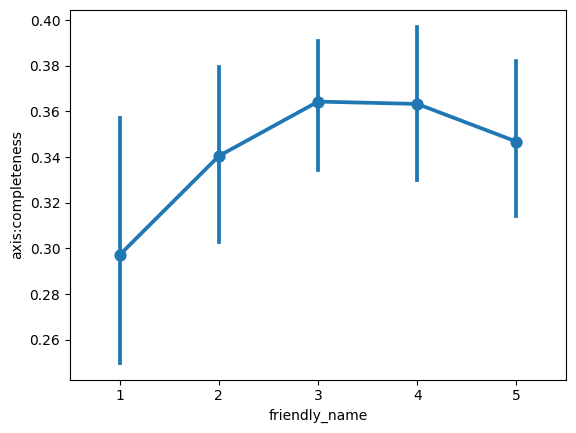

In [38]:
sns.pointplot(granular_results, x="friendly_name", y="axis:completeness")

<Axes: xlabel='friendly_name', ylabel='overall_score'>

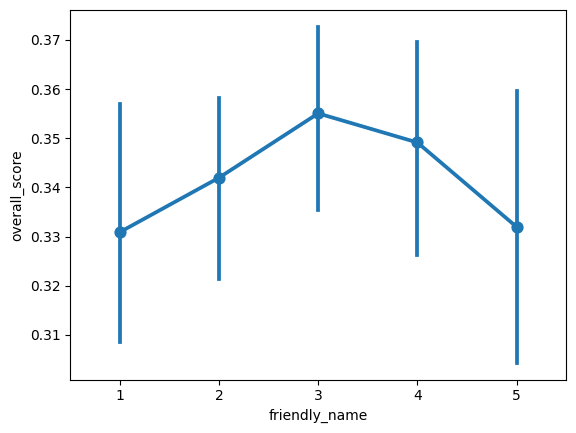

In [39]:
sns.pointplot(granular_results, x="friendly_name", y="overall_score")